In [25]:
import numpy as np
from scipy.integrate import solve_ivp
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

# =========================
# System parameters
# =========================
f_n = 1     # natural frequency (Hz)
alpha = (2*np.pi*f_n)**2       # linear stiffness
beta = 200000       # hardening nonlinearity
delta = 0.02      # damping
f = 0.9       # forcing frequency

# =========================
# Simulation parameters
# =========================
n_periods_total = 2000     # total periods
n_periods_keep  = 1000      # last periods to keep
points_per_period = 200    # time resolution

T = 1 / f
dt = T / points_per_period

# =========================
# Duffing ODE
# =========================
def duffing(t, y, gamma):
	x, v = y
	dxdt = v
	dvdt = -delta*v - alpha*x - beta*x**3 + gamma*np.cos(2*np.pi*f*t)
	return [dxdt, dvdt]


def stroboscopic_sample(t, response, points_per_period, n_periods_keep):
	"""Return the steady-state stroboscopic samples for a periodic response."""
	response = np.asarray(response)
	strobe_indices = np.arange(0, len(t), points_per_period)
	t_strobe = t[strobe_indices]
	response_strobe = response[strobe_indices]

	# Discard transient for the Poincaré map.
	return {
		"t_strobe": t_strobe[-n_periods_keep:],
		"response_poincare": response_strobe[-n_periods_keep:],
	}


def stroboscopic_sample_x_and_xdot(t, x, xdot, points_per_period, n_periods_keep):
	"""Return separate stroboscopic samples for displacement and velocity."""
	x_sample = stroboscopic_sample(t, x, points_per_period, n_periods_keep)
	xdot_sample = stroboscopic_sample(t, xdot, points_per_period, n_periods_keep)
	return {
		"t_strobe": x_sample["t_strobe"],
		"x_poincare": x_sample["response_poincare"],
		"xdot_poincare": xdot_sample["response_poincare"],
	}


# =========================
# Single gamma simulation
# =========================
def simulate_gamma(gamma, store_full_history=False):
	t_span = (0, n_periods_total * T)
	t_eval = np.arange(0, t_span[1], dt)

	sol = solve_ivp(
		duffing,
		t_span,
		y0=[0, 0.0],
		t_eval=t_eval,
		args=(gamma,),
		method='RK45',
		rtol=1e-8,
		atol=1e-9
	)

	x = sol.y[0]
	xdot = sol.y[1]
	t = sol.t

	result = {"gamma": gamma}
	result.update(stroboscopic_sample_x_and_xdot(t, x, xdot, points_per_period, n_periods_keep))

	if store_full_history:
		result.update({
			"t": t,
			"x": x,
			"xdot": xdot,
		})

	return result

# =========================
# Parameter sweep (parallel)
# =========================
gamma_values = np.linspace(0.01, 60, 200)
gamma_values = np.array([0.01,0.1,0.5, 10, 25, 30, 35, 40, 45, 60])

In [26]:

poincare_results = Parallel(n_jobs=-1, verbose=10)(
	delayed(simulate_gamma)(g, store_full_history=True) for g in gamma_values
)
save_dir = Path.cwd() / "sim_dat" / "single_run_beta=0"
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "results.pkl"
with open(save_path, "wb") as f:
	pickle.dump(poincare_results, f)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:   32.8s remaining:  1.3min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:  1.8min remaining:  1.8min
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:  1.9min remaining:   49.1s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  2.1min finished


In [27]:

# =========================
# Collect results
# =========================
gamma_all = np.concatenate([np.full_like(r["x_poincare"], r["gamma"], dtype=float) for r in poincare_results])
x_all = np.concatenate([r["x_poincare"] for r in poincare_results])
xdot_all = np.concatenate([r["xdot_poincare"] for r in poincare_results])

# =========================
# Save full time histories for selected amplitudes
# =========================
phase_gamma_targets = [0.01,0.1,0.5, 10, 25, 30, 45, 60]
phase_histories = {}

# for gamma_target in phase_gamma_targets:
# 	gamma_actual = float(gamma_target)
# 	if gamma_actual not in phase_histories:
# 		phase_histories[gamma_actual] = simulate_gamma(gamma_actual, store_full_history=True)
for r in poincare_results:
	phase_histories[float(r["gamma"])] = r

In [28]:
phase_histories.keys()
# gamma_actual in phase_histories
# gamma_actual

dict_keys([0.01, 0.1, 0.5, 10.0, 25.0, 30.0, 35.0, 40.0, 45.0, 60.0])

In [29]:
x_all.shape[0]/points_per_period 


50.0

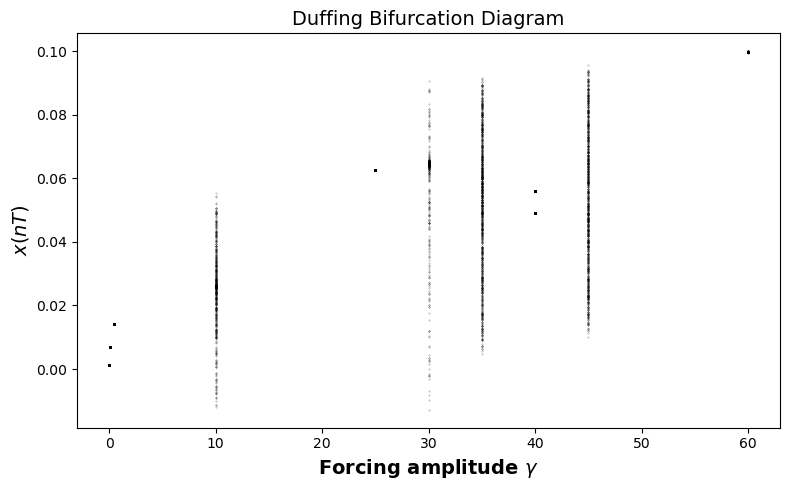

In [30]:
# =========================
# Plot 1: bifurcation diagram
# =========================
plt.figure(figsize=(8, 5))
plt.plot(gamma_all, x_all, '.k', alpha=0.5, markersize=0.5)

plt.xlabel(r'Forcing amplitude $\gamma$', fontsize=14, fontweight='bold')
plt.ylabel(r'$x(nT)$', fontsize=14, fontweight='bold')
plt.title('Duffing Bifurcation Diagram', fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.show()


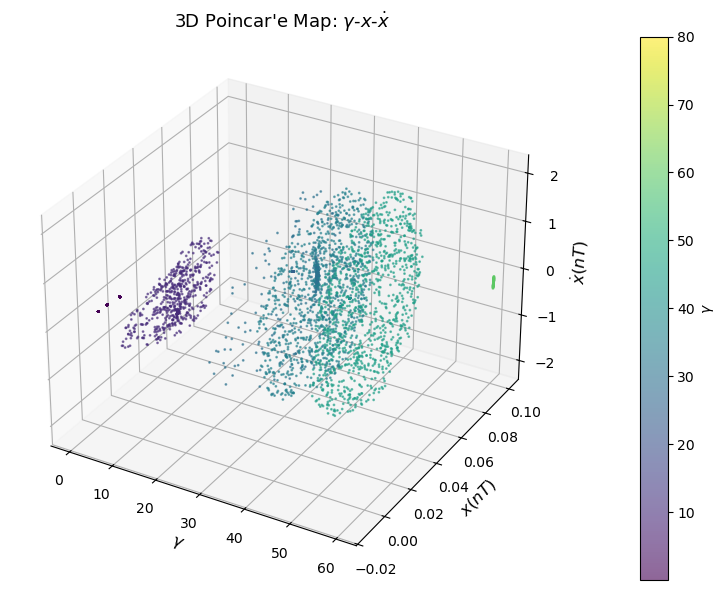

In [31]:
# %matplotlib widget
# =========================
# Plot 2: 3D Poincaré map
# =========================
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

gamma_color_min = float(gamma_all.min())
gamma_color_max = float(80)
sc = ax.scatter(
    gamma_all,
    x_all,
    xdot_all,
    c=gamma_all,
    cmap='viridis',
    s=1,
    alpha=0.6,
    vmin=gamma_color_min,
    vmax=gamma_color_max,
 )

ax.set_xlabel(r'$\gamma$', fontsize=12, fontweight='bold')
ax.set_ylabel(r'$x(nT)$', fontsize=12, fontweight='bold')
ax.set_zlabel(r'$\dot{x}(nT)$', fontsize=12, fontweight='bold')
ax.set_title('3D Poincar\'e Map: $\gamma$-$x$-$\dot{x}$', fontsize=13)
fig.colorbar(sc, ax=ax, pad=0.1, label=r'$\gamma$')
plt.tight_layout()
plt.show()


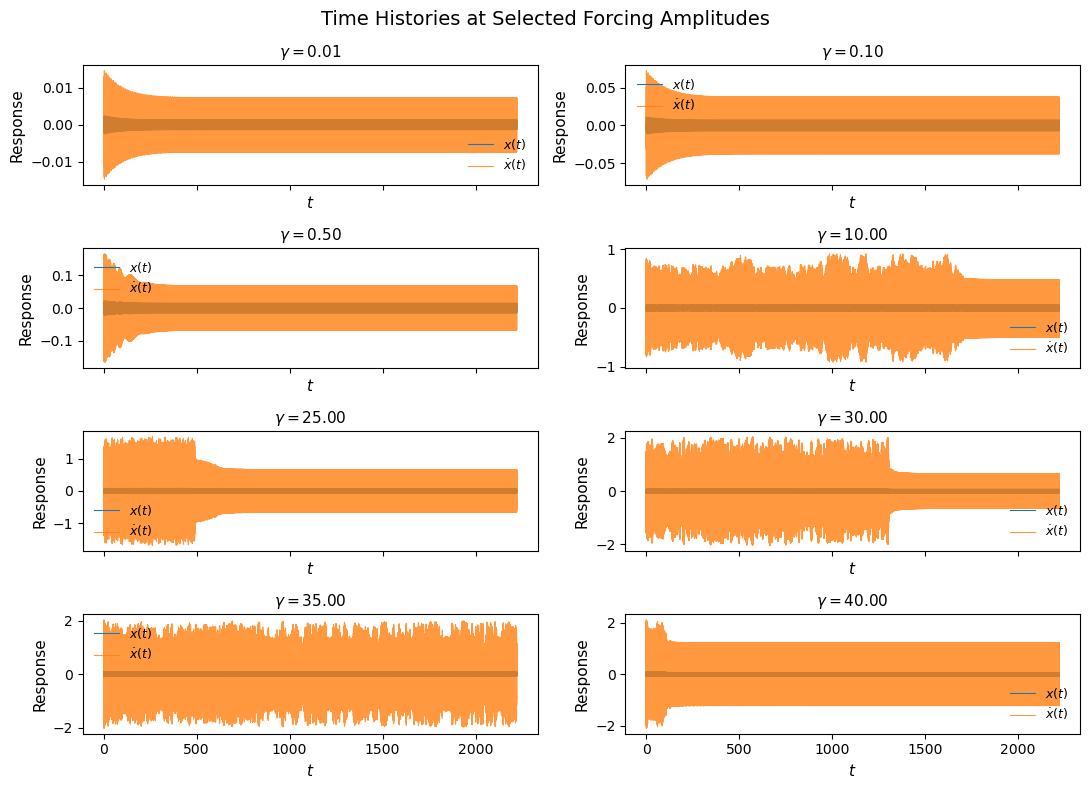

In [32]:
# =========================
# Plot 4: time histories at selected amplitudes
# =========================
fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharex=True)
axes = axes.ravel()

for ax, (gamma_actual, hist) in zip(axes, phase_histories.items()):
    ax.plot(hist["t"], hist["x"], lw=0.8, label=r'$x(t)$')
    ax.plot(hist["t"], hist["xdot"], lw=0.8, label=r'$\dot{x}(t)$', alpha=0.8)
    ax.set_title(rf'$\gamma = {gamma_actual:.2f}$', fontsize=11)
    ax.set_xlabel(r'$t$', fontsize=11)
    ax.set_ylabel(r'Response', fontsize=11)
    ax.grid(False)
    ax.legend(fontsize=9, frameon=False)

for ax in axes[len(phase_histories):]:
    ax.axis('off')

fig.suptitle('Time Histories at Selected Forcing Amplitudes', fontsize=14)
plt.tight_layout()
plt.show()


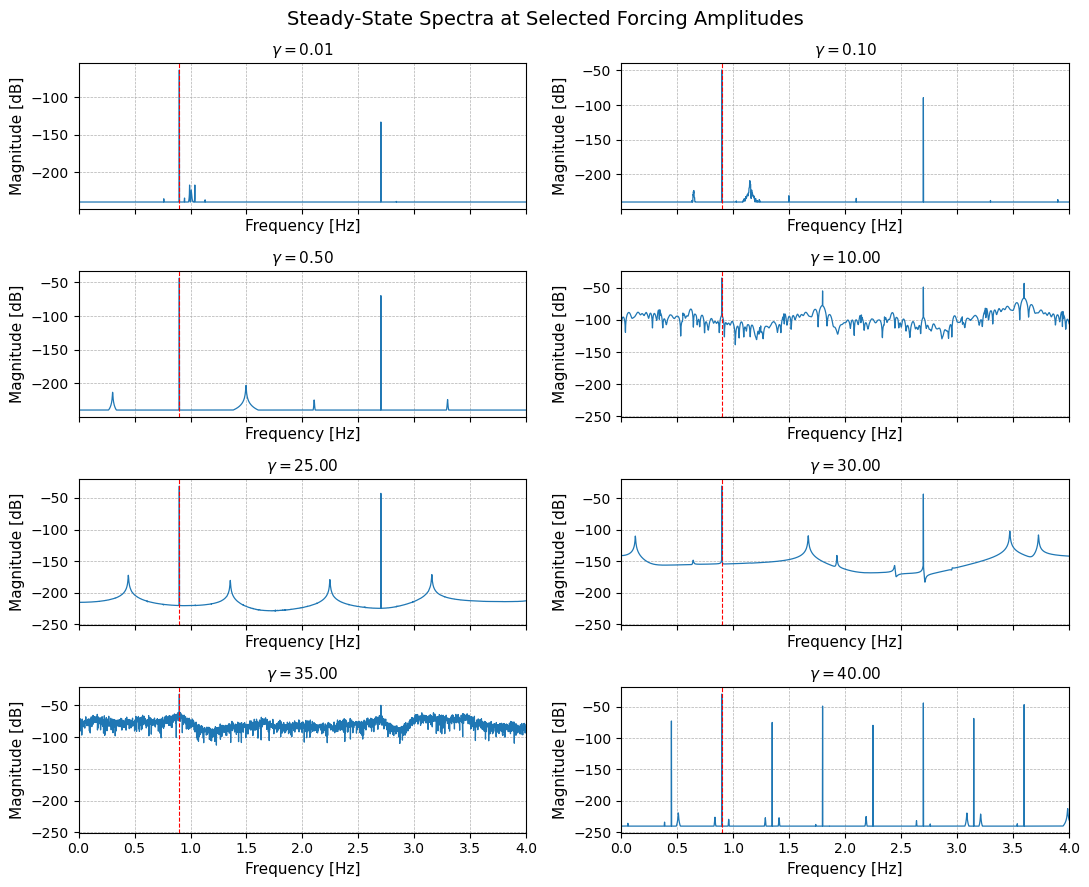

In [33]:
# =========================
# Plot 5: spectra at selected amplitudes
# =========================
fig, axes = plt.subplots(4, 2, figsize=(11, 9), sharex=True)
axes = axes.ravel()

for ax, (gamma_actual, hist) in zip(axes, phase_histories.items()):
    t_hist = hist["t"]
    x_hist = hist["x"]

    start_index = -500 * points_per_period
    t_ss = t_hist[start_index:]
    x_ss = x_hist[start_index:]

    dt_local = float(np.mean(np.diff(t_ss)))
    x_ss = x_ss - np.mean(x_ss)
    n_fft = len(x_ss)
    freqs = np.fft.rfftfreq(n_fft, d=dt_local)
    spectrum = np.abs(np.fft.rfft(x_ss)) / n_fft
    spectrum_db = 20 * np.log10(np.maximum(spectrum, 1e-12))

    ax.plot(freqs, spectrum_db, lw=0.9)
    ax.set_title(rf'$\gamma = {gamma_actual:.2f}$', fontsize=11)
    ax.set_xlabel(r'Frequency [Hz]', fontsize=11)
    ax.set_ylabel(r'Magnitude [dB]', fontsize=11)
    ax.axvline(0.9, color='r', ls='--', lw=0.8, label=r'$f$')
    ax.grid(True, which='both', ls='--', lw=0.5)
    ax.set_xlim(0, 4)

for ax in axes[len(phase_histories):]:
    ax.axis('off')

fig.suptitle('Steady-State Spectra at Selected Forcing Amplitudes', fontsize=14)
plt.tight_layout()
plt.show()


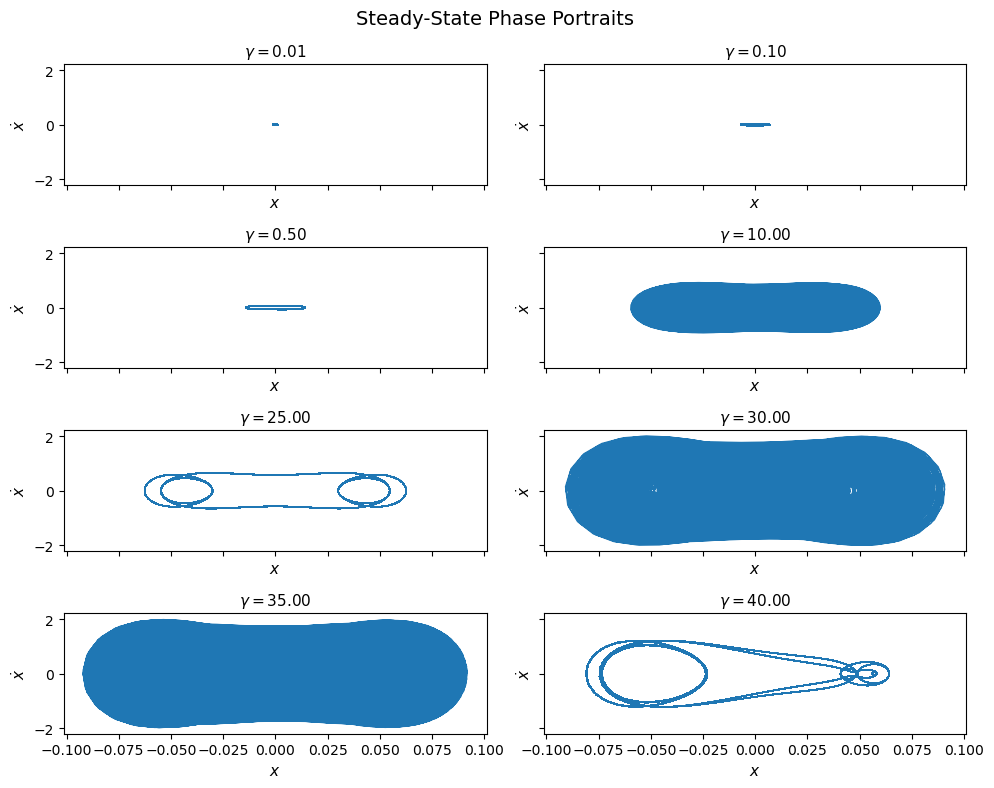

In [34]:

# =========================
# Plot 3: phase portraits at selected amplitudes
# =========================
fig, axes = plt.subplots(4, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (gamma_actual, hist) in zip(axes, phase_histories.items()):
	start_index = -n_periods_keep * points_per_period
	x_phase = hist["x"][start_index:]
	xdot_phase = hist["xdot"][start_index:]
	ax.plot(x_phase, xdot_phase, lw=0.8)
	ax.set_title(rf'$\gamma = {gamma_actual:.2f}$', fontsize=11)
	ax.set_xlabel(r'$x$', fontsize=11)
	ax.set_ylabel(r'$\dot{x}$', fontsize=11)
	ax.grid(False)

for ax in axes[len(phase_histories):]:
	ax.axis('off')

fig.suptitle('Steady-State Phase Portraits', fontsize=14)
plt.tight_layout()
plt.show()